# Inference Demo

In [1]:
%cd ..
import re
import os
from PIL import Image
from models.navidriveVLM import NaviDriveVLM
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

/home/ximeng/Documents/NaviDrive


## Load Model

In [2]:
driver_model_id = "Ximeng0831/NaviDrive-Qwen3-VL-2B-SFT" # load from huggingface
model = NaviDriveVLM(driver_model_id = driver_model_id)

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

## Load Dataset

In [3]:
sample_index = 637 # Available: [41, 100, 120, 323, 558, 637, 1483]

In [4]:
ds = load_dataset("Ximeng0831/NaviDrive-Reasoning", "qwen_32b", split="validation")
data = ds[sample_index]

In [5]:
# Load images: demo figures are stored in ./figures
camera_files = ["CAM_BACK", "CAM_BACK_LEFT", "CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT"]
img_folder = f"figures/{sample_index}"
images = []
for filename in camera_files:
    filename = f"{filename}.jpg"
    img_path = os.path.join(img_folder, filename)
    img = Image.open(img_path).convert('RGB')
    images.append(img)

In [6]:
def filter_to_xy_str(original_str):
    pattern = r"\(([^)]+)\)"
    matches = re.findall(pattern, original_str)
    return ", ".join([f"({p.split(',')[0].strip()}, {p.split(',')[1].strip()})" if len(p.split(',')) > 2 else f"({p})" for p in matches])

## Prompts

In [7]:
ego_status_prompt = (
    "Current Dynamics:\n"
    f"- Velocity: {data['vel_val']:.2f} m/s\n"
    f"- Yaw Rate: {data['yr_val']:.2f} rad/s\n"
    f"- Acceleration (Longitudinal x, Lateral y): {data['acc_val']}\n"
    f"Past Trajectory (2Hz): {filter_to_xy_str(data['wp_past'])}\n"
    f"High-level Command: {data['command']}\n\n"
)

In [8]:
navi_user_prompt = (
                    "Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.\n"
                    "1:BACK, 2:BACK_LEFT, 3:FRONT_LEFT, 4:FRONT, 5:FRONT_RIGHT, 6:BACK_RIGHT,.\n"
                    f"{ego_status_prompt}"
                    "Task: Analyze the current situation and provide the safest next action with reasons."
                    )

In [9]:
driver_user_prompt = (
                    f"{ego_status_prompt}"
                    "Predict the next 12 waypoints: (x1, y1), (x2, y2), ..., (x12, y12)."
                    )

## Run the Model

In [10]:
reason, all_pred_waypoints = model(navi_user_prompt, driver_user_prompt, images)

## Print the Results

In [11]:
print(reason)

Perception: The vehicle is driving straight on a wet urban road with moderate traffic. Visibility is reduced due to rain and fog, and the road surface is reflective. Traffic signs and lane markings are visible, but obscured by weather conditions. No immediate dynamic hazards are detected in the immediate vicinity.

Action: Maintain current straight trajectory with cautious speed.

Reasoning: The road conditions are wet and visibility is reduced, which increases braking distance and risk of hydroplaning. Since no immediate obstacles or traffic violations are observed, continuing straight aligns with the high-level command. The vehicle should proceed cautiously, monitoring for potential hazards that may emerge as visibility improves or as the vehicle moves forward.


In [12]:
for i in range(len(all_pred_waypoints)):
    print(f"Waypoint {i+1}: {all_pred_waypoints[i]}")

Waypoint 1: [[4.33, -0.02], [8.73, -0.03], [13.16, -0.04], [17.63, -0.05], [22.04, -0.05], [26.44, -0.07], [30.85, -0.09], [35.28, -0.12], [39.67, -0.14], [44.06, -0.17], [48.42, -0.2], [52.77, -0.22]]
Waypoint 2: [[4.34, -0.02], [8.75, -0.05], [13.21, -0.08], [17.75, -0.11], [22.26, -0.14], [26.78, -0.18], [31.31, -0.22], [35.82, -0.26], [40.34, -0.3], [44.83, -0.35], [49.36, -0.41], [53.9, -0.48]]
Waypoint 3: [[4.27, -0.03], [8.57, -0.05], [12.84, -0.08], [17.08, -0.11], [21.24, -0.15], [25.36, -0.18], [29.49, -0.2], [33.65, -0.22], [37.83, -0.25], [42.05, -0.29], [46.26, -0.31], [50.49, -0.32]]
Waypoint 4: [[4.26, -0.02], [8.52, -0.05], [12.76, -0.09], [17.03, -0.13], [21.34, -0.17], [25.68, -0.22], [29.98, -0.27], [34.31, -0.31], [38.67, -0.35], [43.06, -0.39], [47.45, -0.42], [51.86, -0.44]]
Waypoint 5: [[4.33, -0.03], [8.75, -0.06], [13.23, -0.1], [17.85, -0.13], [22.49, -0.17], [27.17, -0.2], [31.85, -0.24], [36.56, -0.28], [41.31, -0.33], [46.07, -0.39], [50.84, -0.44], [55.65,

In [13]:
print("Ground Truth: ", filter_to_xy_str(data['wp_future']))

Ground Truth:  (4.27, -0.03), (8.63, -0.06), (13.07, -0.09), (17.49, -0.10), (21.95, -0.11), (26.37, -0.13), (30.82, -0.14), (35.28, -0.13), (39.72, -0.13), (44.17, -0.15), (48.80, -0.16), (53.32, -0.16)


## Visualization

In [14]:
def plot_gt_and_pred(gt_str, pred_wp=None):
    pattern = r"\(([-+]?\d*\.?\d+)\s*,\s*([-+]?\d*\.?\d+)\s*,\s*([-+]?\d*\.?\d+)\)"
    matches = re.findall(pattern, gt_str)
        
    gt_wp = np.array([[float(val) for val in m] for m in matches])
    gt_x = np.insert(gt_wp[:, 0], 0, 0.0)
    gt_y = np.insert(gt_wp[:, 1], 0, 0.0)
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(0, 0, marker='*', color='red', markersize=15, label='Ego', zorder=5)
    
    # Ground Truth
    plt.plot(gt_x, gt_y, marker='s', color='green', linewidth=3, markersize=6, alpha=0.5, label='GT', zorder=4)
    
    # Prediction
    if pred_wp is not None:
        ades = []
        for i, traj in enumerate(pred_wp):
            traj_np = np.array(traj)
            if traj_np.size > 0:
                distances = np.linalg.norm(traj_np[:, :2] - gt_wp[:, :2], axis=1)
                ade = np.mean(distances)
                ades.append(ade)
                traj_x = np.insert(traj_np[:, 0], 0, 0.0)
                traj_y = np.insert(traj_np[:, 1], 0, 0.0)
                plt.plot(traj_x, traj_y, marker='o', markersize=4, 
                         linestyle='--', alpha=0.6, label=f'Pred{i+1}')

    best_idx = np.argmin(ades) if ades else -1
    best_wp = np.array(pred_wp[best_idx])
    
    plt.title('Ground Truth vs Prediction', fontsize=14)
    plt.xlabel('X - Forward Distance (m)', fontsize=12)
    plt.ylabel('Y - Lateral Distance (m)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
    plt.tight_layout()
    plt.show()
    
    return best_wp, gt_wp

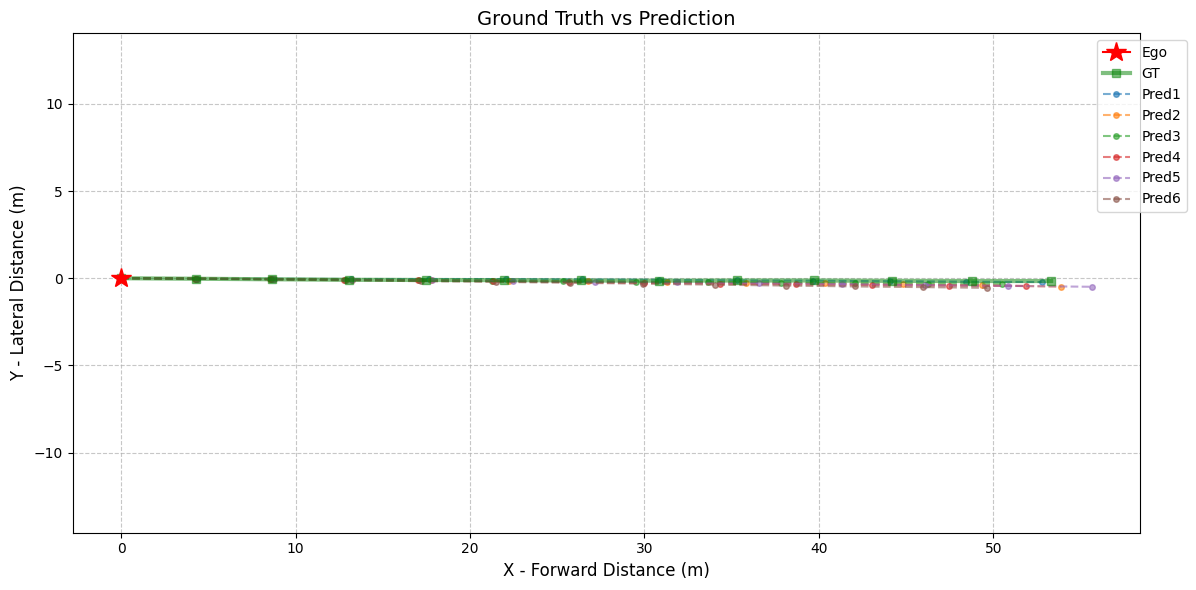

In [15]:
best_wp, gt_wp = plot_gt_and_pred(data['wp_future'], all_pred_waypoints)

## Rendering

**Note:** Running this section requires downloading the [nuScenes dataset](https://www.nuscenes.org/nuscenes#download).

In [16]:
from utils.results_utils import project_wp_to_image
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-trainval', dataroot='/home/ximeng/Dataset/nuscenes_full_v1_0/', verbose=False) # dataroot is the path to the nuScenes dataset

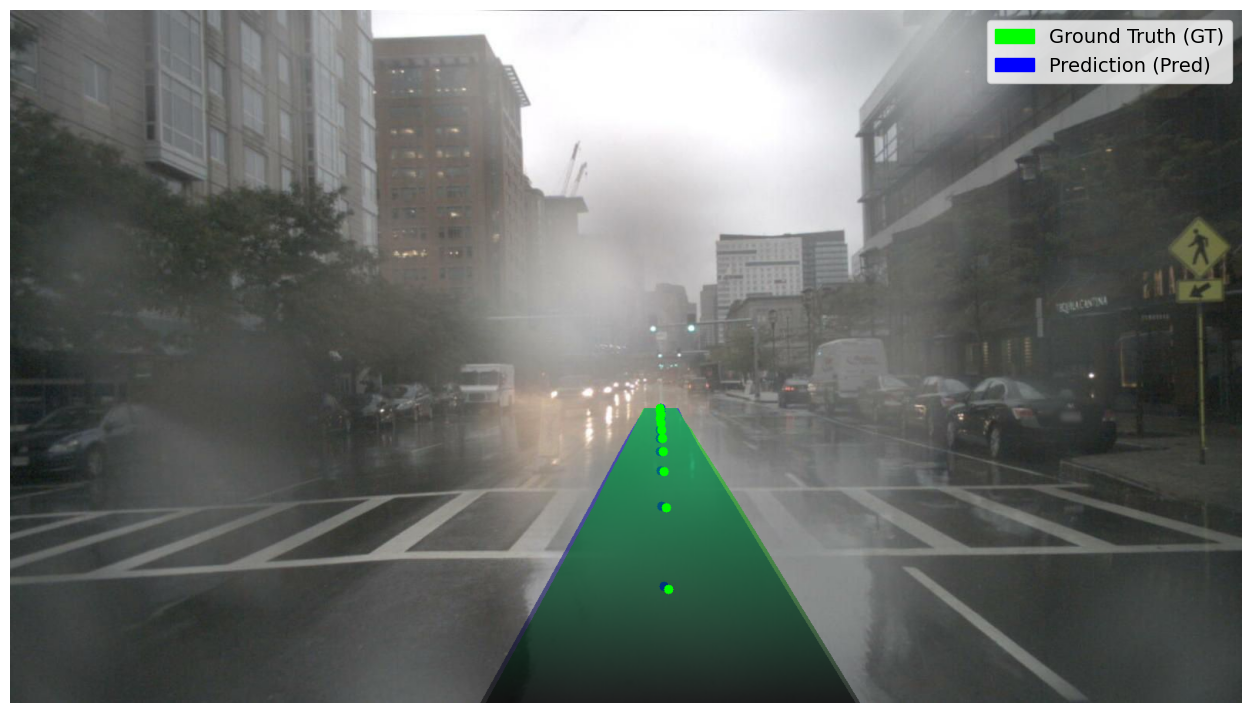

In [17]:
token = data['token'][0]
img_np = np.array(images[3])
vis_img = project_wp_to_image(nusc, token, best_wp, img_np, color_waypoints=(0, 0, 255), color_polygon=(0, 0, 255))
vis_img = project_wp_to_image(nusc, token, gt_wp, vis_img, color_waypoints=(0, 255, 0), color_polygon=(0, 255, 0))
plt.figure(figsize=(16, 9))
gt_patch = mpatches.Patch(color=(0, 1, 0), label='Ground Truth (GT)')
pred_patch = mpatches.Patch(color=(0, 0, 1), label='Prediction (Pred)')
plt.legend(handles=[gt_patch, pred_patch], loc='upper right', fontsize=14, framealpha=0.8)
plt.axis('off')
plt.imshow(vis_img)

In [18]:
print(reason)

Perception: The vehicle is driving straight on a wet urban road with moderate traffic. Visibility is reduced due to rain and fog, and the road surface is reflective. Traffic signs and lane markings are visible, but obscured by weather conditions. No immediate dynamic hazards are detected in the immediate vicinity.

Action: Maintain current straight trajectory with cautious speed.

Reasoning: The road conditions are wet and visibility is reduced, which increases braking distance and risk of hydroplaning. Since no immediate obstacles or traffic violations are observed, continuing straight aligns with the high-level command. The vehicle should proceed cautiously, monitoring for potential hazards that may emerge as visibility improves or as the vehicle moves forward.
